<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Caso-taller:  Recomendando Música

El objetivo de este caso-taller es construir un sistema de recomendación de Música utilizando los datos de [Last.fm](https://www.last.fm/) provistos  abiertamente por [grouplens](https://grouplens.org/about/what-is-grouplens/) para: **"avanzar la teoría y la práctica de la computación social mediante la construcción y la comprensión de sistemas *(de recomendación)* utilizados por personas reales".**

Los datos contienen información sobre artistas, usuarios, y las veces que estos escucharon sus canciones. Las bases se encuentran en los `Archivos de Laboratorio` en la carpeta `data`, allí también está disponible un archivo [README](data/readme.txt) que contiene más información sobre las bases.


## Instrucciones generales

1. Para desarrollar el *cuaderno*, primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el  tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from scipy.linalg import svd
from apyori import apriori

### 1. Carga de datos 

En la carpeta `data` se encuentran los archivos:

   - `artists.dat`  que contienen el identificador del artista (`id`), nombre (`name`), link a la página del artista en last.fm (`url`), y link a la imagen del usuario (`pictureURL`), vale aclarar que varios de estos links están rotos. 
   - `user_artists.dat`  que contiene identificador del usuario (`userID`), nombre del artista que escuchó (`artistID`), y las veces que los escuchó (`weight`).

Cargue estos datos en su *cuaderno*:

   1. Para la base de artistas seleccione las columnas de identificador de artista (`id`) y nombre (`name`). Renombre estas columnas para poder hacer la unión con la base `user_artists.dat`.
   2. Para la base de usuarios y artistas, renombre las columnas de forma tal que se mantenga la consistencia para unir con la base anterior, y renombre la columna `weight` a `nro_reproducciones`.
   3. Una estas bases.
   

In [2]:
# Utilice este espacio para escribir el código.
artistas=pd.read_csv(r"data\artists.dat",delimiter="\t",usecols=["id","name"])
artistas.rename(columns={"id":"artistID","name":"artist_name"},inplace=True)
usuarios=pd.read_csv(r"data\user_artists.dat",delimiter="\t")
usuarios.rename(columns={"weight":"nro_reproducciones"},inplace=True)
df=pd.merge(usuarios,artistas,on="artistID",how="left")
df.head()


,userID,artistID,nro_reproducciones,artist_name
0,2,51,13883,Duran Duran
1,2,52,11690,Morcheeba
2,2,53,11351,Air
3,2,54,10300,Hooverphonic
4,2,55,8983,Kylie Minogue


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).
1. Se carga el archivo artist.dat y se indica solo cargar las columnas id y name
2. Se renombran las columnas de artist.dat siguiendo {"id":"artistID","name":"artist_name"}
3. Se carga el archivo user_artists.dat
4. Se renombran las columnas de user_artists.dat siguiendo {"weight":"nro_reproducciones"}
5. A usuario se le une la tabla artistas bajo el campo artistID con un left

### 2. Análisis preliminar. 

En esta sección exploraremos la base. Para ello responda las siguientes preguntas.

#### 2.1 ¿Cuantos usuarios y artistas hay en la base?


In [3]:
print(f"Existen {df['userID'].nunique():,} usuarios en la base")
print(f"Existen {df['artistID'].nunique():,} artistas en la base")

Existen 1,892 usuarios en la base
Existen 17,632 artistas en la base



#### 2.2 ¿Cuáles es la distribución de probabilidad del consumo por artista? (haga el calculo sin ponderar y ponderando por el numero de reproducciones) ¿Qué podemos inferir a partir de la comparación de ambas?

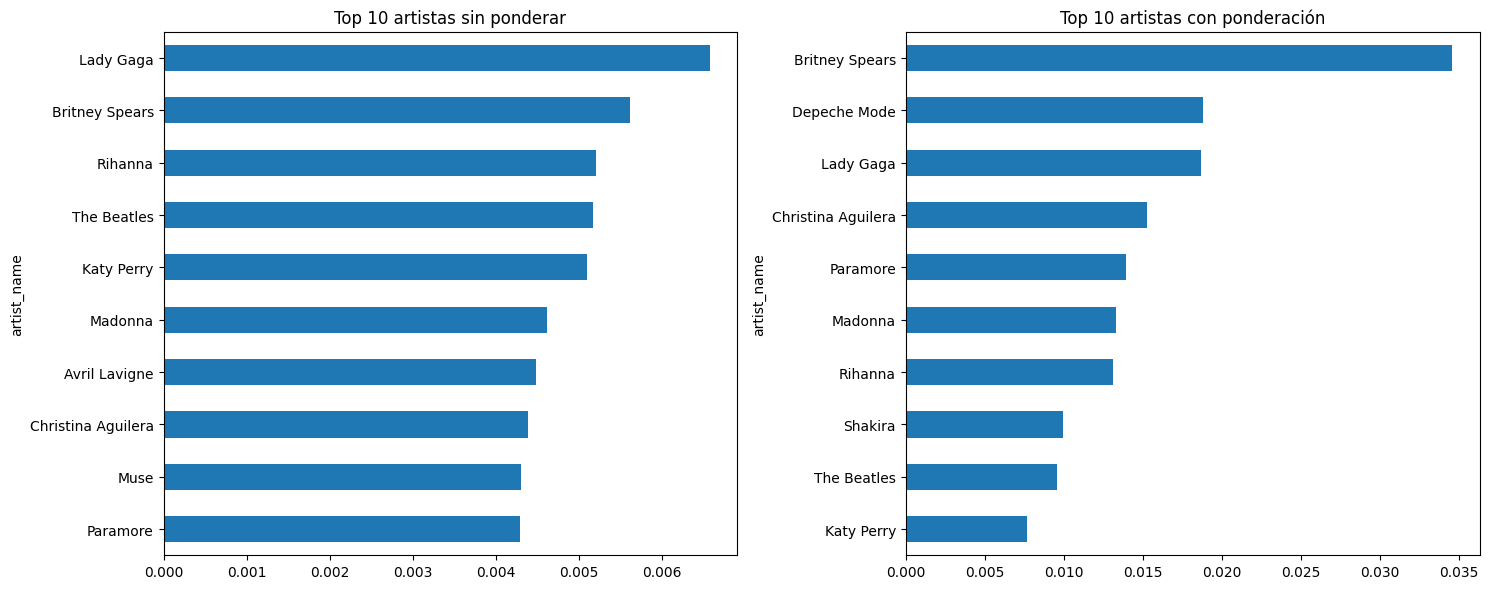

In [4]:
# Utilice este espacio para escribir el código.
# Distribución de probabilidad de consimo por arista sin ponderar
sin_ponderar= df["artist_name"].value_counts(normalize=True).sort_values(ascending=False)
# Distribución de probabilidad de consumo por arista con ponderación
conteo=df.groupby("artist_name")["nro_reproducciones"].sum().sort_values(ascending=False)
con_ponderar= conteo/conteo.sum()

top_sin_ponderar=sin_ponderar.head(10)
top_con_ponderar=con_ponderar.head(10)
fig, axes= plt.subplots(1,2,figsize=(15,6))
top_sin_ponderar.plot(kind="barh",ax=axes[0],title="Top 10 artistas sin ponderar")
top_con_ponderar.plot(kind="barh",ax=axes[1],title="Top 10 artistas con ponderación")
axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

Cuando calculamos la probabiliad de distribucion sin ponderar estamos calculando la probabilidad de seleccionar un artista independienttemente de sus reproducciones. En cambio cuando usamos la ponderación, estaríamos calculando la probabilidad de que alseleccionar una canción sea de un artista X.

En otras palabras, sin ponderación mostramos los artistas más escuchados por cantidad de usuarios. Con ponderación, mostraremos los artistas con mayor concentración de reproducciones.

Se puede apreciar que Lady gaga es la artista más escuchada en general, sin embargo, al incluir la ponderación vemos que cae a la posición # 3 y nos muestra que Britney, puede tener menos oyentes pero es esuchada más veces por lo usuarios vs Lady Gaga

#### 2.3 Para el usuario 8 (`userID==8`) ¿cuál es la distribución de reproducción de artistas basado en el número de reproducciones relativas?. Presente sus resultados usando tablas y/o gráficas. ¿Encuentra algún patrón en los artistas que escucha y las veces que reproduce? ¿Podemos decir algo de sus preferencias?


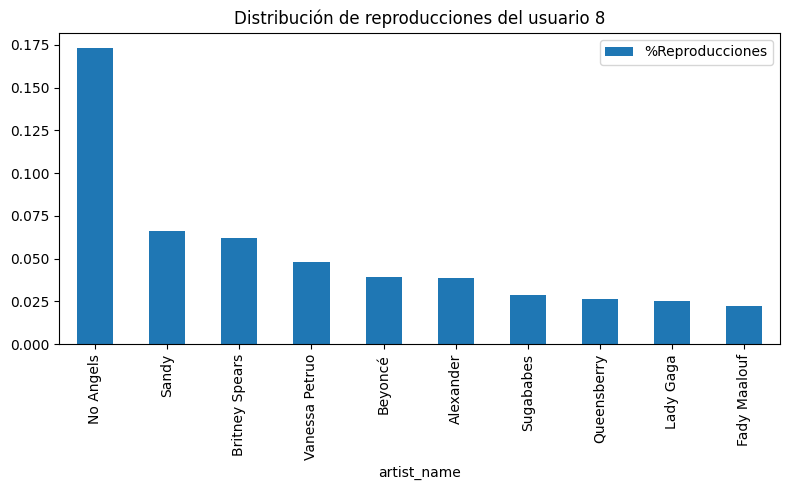

,userID,artistID,nro_reproducciones,artist_name,%Reproducciones
317,8,334,6291,No Angels,0.173406
318,8,335,2396,Sandy,0.066044
307,8,289,2258,Britney Spears,0.062240
319,8,336,1735,Vanessa Petruo,0.047824
310,8,295,1425,Beyoncé,0.039279
320,8,337,1407,Alexander,0.038783
311,8,296,1039,Sugababes,0.028639
321,8,338,963,Queensberry,0.026544
301,8,89,921,Lady Gaga,0.025387
322,8,339,819,Fady Maalouf,0.022575


In [5]:
# Utilice este espacio para escribir el código.
usuario8=df[df["userID"]==8].copy()
usuario8["%Reproducciones"]=usuario8["nro_reproducciones"]/usuario8["nro_reproducciones"].sum()
usuario8=usuario8.sort_values(by="%Reproducciones",ascending=False)
top_10_usuario8=usuario8.head(10)
fig, ax= plt.subplots(figsize=(8,5))
top_10_usuario8.plot(kind="bar",x="artist_name",y="%Reproducciones",ax=ax,title="Distribución de reproducciones del usuario 8")
plt.tight_layout()
plt.show()
usuario8.head(10)

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

El usuario 8 parece concentrar una gran parte de reprpducciones en un único artista: "No Angeles" (17%). Sandy y Britney ocupan alrededor del 12% de sus reproducciones. entre estos 3 artistas se concentran casi el 30% de sus reproducciones. 

### 3. Generando Recomendaciones

En esta sección nos interesa generar recomendaciones ***nuevas y relevantes*** para el usuario 8 (`userID==8`). Para ello vamos a generar distintos sistemas de recomendación y comparar las recomendaciones generadas.

#### 3.1. Filtrado colaborativo sencillo: promedios simples.

Usando el promedio simple basado en el número de usuarios que escucha un artista (sin considerar el número de veces que estos usuarios reproducen al artista) genere una tabla y/o gráfica con 10 recomendaciones de artistas para este usuario. Explique con cuidado su procedimiento y justifique sus elecciones.

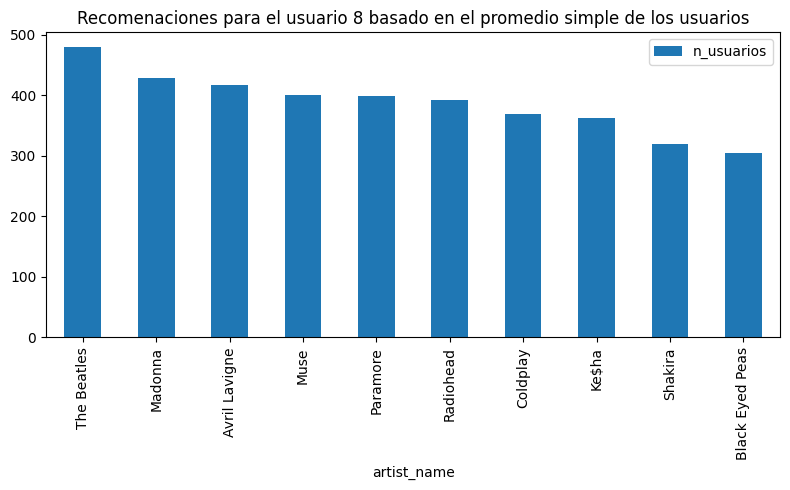

,artistID,artist_name,n_usuarios
221,227,The Beatles,480
61,67,Madonna,429
327,333,Avril Lavigne,417
184,190,Muse,400
492,498,Paramore,399
148,154,Radiohead,393
59,65,Coldplay,369
460,466,Ke$ha,362
695,701,Shakira,319
300,306,Black Eyed Peas,304


In [6]:
# Utilice este espacio para escribir el código.
total_usuarios = df['userID'].nunique()
df_pivot=df.groupby(['artistID', 'artist_name'])['userID'].nunique().reset_index(name='n_usuarios')

conjunto_artistas=set(df.loc[df['userID'] == 8, 'artistID'])
recomendaciones=df_pivot.loc[~df_pivot["artistID"].isin(conjunto_artistas)].sort_values(by="n_usuarios",ascending=False).head(10)
fig, ax= plt.subplots(figsize=(8,5))
recomendaciones.plot(kind="bar",x="artist_name",y="n_usuarios",ax=ax,title="Recomenaciones para el usuario 8 basado en el promedio simple de los usuarios")
plt.tight_layout()
plt.show()
recomendaciones


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).
1. Para cada artista se cuentan la cantidad de usuarios unicos que los escuchan y se nombra la columna como n_usuarios. Se usa groupby
2. Se guarda en un conjunto los artistas que esucha el usuario 8 usando set
3. Se obtienen los registros de df_pivot que comparte el usuario 8 y luego se usa la negación de este filtro para excluirlos de la tabla. Posteriormente se ordenan de mayor a menor por la variable n_usuarios y se muestran los primeros 10 como recomendaciones.


#### 3.2.  Filtrado colaborativo sencillo: promedios ponderados.

Utilice un promedio ponderado para generar las recomendaciones. Considere el número de veces que los usuarios reproducen al artista. En otras palabras, genere un ponderador que use el número de veces que el artista fue reproducido (`nro_reproducciones`). Este método pondera la popularidad de un artista, combinando el número de usuarios que lo escuchan con la frecuencia de reproducción, de manera que los artistas con más reproducciones reciban una mayor ponderación.

Genere una tabla y/o gráfica con las 10 principales recomendaciones de artistas para este usuario. Explique detalladamente su procedimiento y justifique sus elecciones. Compare estas recomendaciones con las del sistema implementado en el paso anterior.

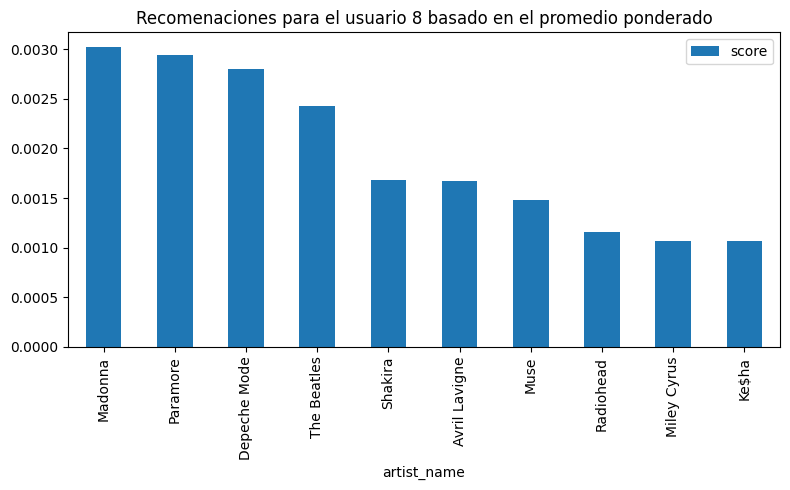

,artistID,artist_name,n_usuarios,total_reproducciones,ponderacion_repro,ponderacion_usuarios,score
61,67,Madonna,429,921198,0.013315,0.226744,0.003019
492,498,Paramore,399,963449,0.013926,0.210888,0.002937
66,72,Depeche Mode,282,1301308,0.018809,0.149049,0.002804
221,227,The Beatles,480,662116,0.009570,0.253700,0.002428
695,701,Shakira,319,688529,0.009952,0.168605,0.001678
327,333,Avril Lavigne,417,525844,0.007601,0.220402,0.001675
184,190,Muse,400,485076,0.007011,0.211416,0.001482
148,154,Radiohead,393,385306,0.005569,0.207717,0.001157
455,461,Miley Cyrus,286,489065,0.007069,0.151163,0.001069
460,466,Ke$ha,362,384405,0.005556,0.191332,0.001063


In [7]:
# Correcto
df_pivot_pond=df.groupby(['artistID', 'artist_name']).agg(
    n_usuarios=('userID', 'nunique'),
    total_reproducciones=('nro_reproducciones', 'sum')
).reset_index()
df_pivot_pond['ponderacion_repro'] = df_pivot_pond['total_reproducciones'] / df_pivot_pond['total_reproducciones'].sum()
df_pivot_pond['ponderacion_usuarios']= df_pivot_pond['n_usuarios'] / total_usuarios 
df_pivot_pond["score"]= df_pivot_pond['ponderacion_repro'] * df_pivot_pond['ponderacion_usuarios']
df_pivot_pond=df_pivot_pond.sort_values(by="score",ascending=False)
recomendaciones_pond=df_pivot_pond.loc[~df_pivot_pond["artistID"]
                                       .isin(conjunto_artistas)
                                       ].sort_values(by="score",ascending=False).head(10)

fig, ax= plt.subplots(figsize=(8,5))
recomendaciones_pond.plot(kind="bar",x="artist_name",y="score",ax=ax,title="Recomenaciones para el usuario 8 basado en el promedio ponderado")
plt.tight_layout()
plt.show()
recomendaciones_pond

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).
1. Para cada artista se cuentan la cantidad de usuarios unicos que los escuchan y se nombra la columna como n_usuarios. Se acumulan la cantidad de reproducciones para cada artista dado los usuarios y se guarda en al variable total_reproducciones.  Se usa groupby
2. Se guarda en un conjunto los artistas que esucha el usuario 8 usando set (sección anterior)
3. Se calcula el peso para cada artista para n_usuarios y para total_reproducciones para obtener : ponderacion_usuarios y ponderacion_repro
4. Por último se multiplican las ponderaciones obtenidas para tener un score de importancia, donde tendremos en el top de artistas con mas reproduccione sy cantidad de oyentes.
5. Se obtienen los registros de df_pivot que comparte el usuario 8 y luego se usa la negación de este filtro para excluirlos de la tabla. Posteriormente se ordenan de mayor a menor por la variable n_usuarios y se muestran los primeros 10 como recomendaciones.

#### 3.3.  Filtrado colaborativo sencillo: similitud de coseno.

Usando el promedio ponderado de reproducciones genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario. Para generar los pesos utilice la distancia de coseno. Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en el paso anterior.

In [8]:
# Utilice este espacio para escribir el código.
reproducciones_matriz=df.pivot_table(index="artistID",columns="userID",values="nro_reproducciones",aggfunc="sum",fill_value=0)
reproducciones_matriz

userID,2,3,4,5,6,7,8,9,10,11,...,2090,2091,2092,2093,2094,2095,2096,2097,2099,2100
artistID,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,408
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18741,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18742,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18743,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
#Calculamos la similitud de coseno 
cosine_sim = cosine_similarity(reproducciones_matriz, reproducciones_matriz)

# Transformamos la matriz resultante en un dataframe
cosine_sim = pd.DataFrame(cosine_sim, index=reproducciones_matriz.index, columns=reproducciones_matriz.index)
cosine_sim

artistID,1,2,3,4,5,6,7,8,9,10,...,18736,18737,18738,18739,18740,18741,18742,18743,18744,18745
artistID,,,,,,,,,,,,,,,,,,,,,
1,1.0,0.00000,0.0,0.0,0.00000,0.000000,0.008784,0.032075,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.00000,0.0,0.0,0.20774,0.000000,0.010696,0.000000,0.102094,0.387653,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.00000,1.0,0.0,0.00000,0.205607,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.00000,0.0,1.0,0.00000,0.000000,0.019742,0.049547,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.20774,0.0,0.0,1.00000,0.000000,0.042728,0.000000,0.190713,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18741,0.0,0.00000,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
18742,0.0,0.00000,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
18743,0.0,0.00000,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0


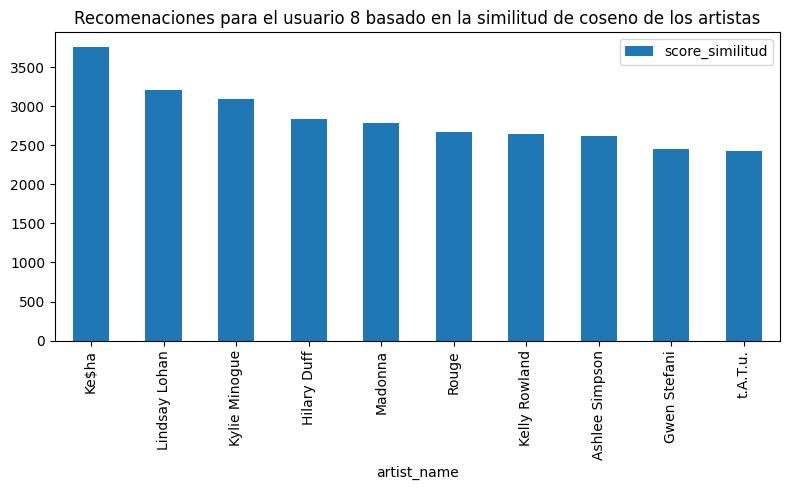

,artistID,score_similitud,artist_name
0,466,3758.922518,Ke$ha
1,523,3206.966055,Lindsay Lohan
2,55,3092.208337,Kylie Minogue
3,318,2839.219603,Hilary Duff
4,67,2785.194089,Madonna
5,4350,2667.223971,Rouge
6,332,2651.243711,Kelly Rowland
7,293,2613.696671,Ashlee Simpson
8,525,2457.115509,Gwen Stefani
9,972,2431.339088,t.A.T.u.


In [10]:
usuario_objetivo=8
vector_usuario=reproducciones_matriz[usuario_objetivo].values

vector_usuario_norm = vector_usuario / vector_usuario.sum() #pesos relativos

scores = cosine_sim.values @ vector_usuario #producto entre la matriz de similitud y el vector del usuario

escuchados_mask = vector_usuario > 0 # filtro para eliminar los artistas ya escuchados
scores[escuchados_mask] = -np.inf # asignamos -inf a los artistas ya escuchados para que no sean recomendados

top_norm = np.argsort(-scores)[:10]


artistas_recomendados = reproducciones_matriz.index[top_norm]
scores_recomendados = scores[top_norm]

resultado = pd.DataFrame({
    "artistID": artistas_recomendados,
    "score_similitud": scores_recomendados
})

resultado = pd.merge(resultado, artistas, on="artistID", how="left")
fig, ax= plt.subplots(figsize=(8,5))
resultado.plot(kind="bar",x="artist_name",y="score_similitud",ax=ax,title="Recomenaciones para el usuario 8 basado en la similitud de coseno de los artistas")
plt.tight_layout()
plt.show()
resultado

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).
1. Se crea una matriz con artistas en filas y usuarios en columnas con las reproducciones como valores
2. Se usa la similitud coseno para calcular que tan parecidos son los artistas en función de los usuarios que los escuchan.Da como resultado la matriz cosine_sim que indica que tan parecido es un artista al otro
3. Se toma el vector del usuario 8 que nos arroja las reproducciones por artistas y normalizamos para obtener los pesos relativos de cada artista
4. Se multiplca la matriz cosine_sim por el vector normalizado del usuario 8 esto combina el peso relativo de cada artista del usuario vs que tan parecidos es cada artista a los demás.
5. Se filtran los artistas ya escuchado y se les asigna un valor de -np.inf para que no sea recomendado
6. Se toma el top 10 de artistas

#### 3.4.  Filtrado colaborativo usando SVD


Usando la descomposición en valores singulares (SVD) genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario.  Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en los pasos anteriores.


In [11]:
# Utilice este espacio para escribir el código.
reproducciones_matriz
M = reproducciones_matriz.values 
U, S, Vt = svd(M, full_matrices=False)

k = 10
U_k = U[:, :k]
S_k = np.diag(S[:k])
Vh_k = Vt[:k, :]

matriz_reconstruida = np.dot(np.dot(U_k, S_k), Vh_k)
matriz_reconstruida_df = pd.DataFrame(matriz_reconstruida, index=reproducciones_matriz.index, columns=reproducciones_matriz.columns)

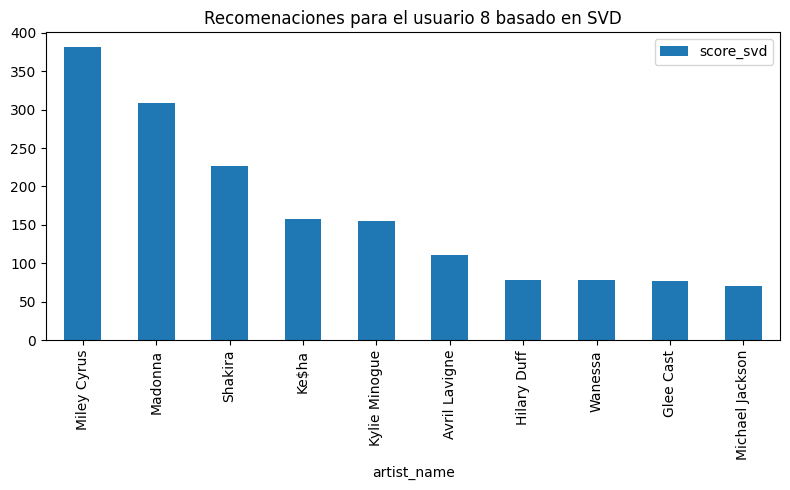

,artistID,score_svd,artist_name
0,461,381.493741,Miley Cyrus
1,67,308.760474,Madonna
2,701,226.743758,Shakira
3,466,157.393768,Ke$ha
4,55,155.527717,Kylie Minogue
5,333,111.116395,Avril Lavigne
6,318,77.843742,Hilary Duff
7,2548,77.707786,Wanessa
8,679,76.389384,Glee Cast
9,157,71.137374,Michael Jackson


In [12]:
predicciones_usuario = matriz_reconstruida_df[usuario_objetivo]
escuchados = reproducciones_matriz[usuario_objetivo] > 0
predicciones_usuario = predicciones_usuario[~escuchados]

recomendaciones_top10 = predicciones_usuario.sort_values(ascending=False).head(10)
resultado_svd = pd.merge(recomendaciones_top10, artistas, on="artistID", how="left")
resultado_svd.rename(columns={usuario_objetivo:"score_svd"},inplace=True)
fig, ax= plt.subplots(figsize=(8,5))
resultado_svd.plot(kind="bar",x="artist_name",y="score_svd",ax=ax,title="Recomenaciones para el usuario 8 basado en SVD")
plt.tight_layout()
plt.show()
resultado_svd


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 3.5.  Filtrado colaborativo usando Análisis de Canasta de Compra

Usando  el algoritmo `Apriori` genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario.  Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en los pasos anteriores. Esto puede tomar mucho tiempo, sea cuidadoso al elegir los hiper-parámetors del modelo, utilice los resultados de las estadísticas descriptivas para elegir sus hiper-parámetros, y genere solo reglas con 2 elementos. (Puede también aprovechar los recursos de [Google Colab](https://colab.research.google.com/))


In [ ]:
# Utilice este espacio para escribir el código.
records = []
for i in df['userID'].unique():
    records.append(list(set(df.loc[df['userID']==i, 'artistID']))) #usamos set para solo tener valores unicos por artista

In [35]:
association_rules = apriori(records, min_support=0.005, min_confidence=0.5, min_lift=3,max_length=2)
association_results = list(association_rules)
print("Derivamos {} reglas de asociación.".format(len(association_results)))

Derivamos 3220 reglas de asociación.


In [36]:
usuario_8_apriori = pd.DataFrame(columns=['artistID','support','confidence','lift'])
loc = 0

for rule in association_results:
    stat = rule.ordered_statistics[0]  # Primer OrderedStatistic
    antecedent = set(stat.items_base)
    consequent = next(iter(stat.items_add)) 
    support = rule.support
    confidence = stat.confidence
    lift = stat.lift
    
    if antecedent.issubset(conjunto_artistas) and consequent not in conjunto_artistas:
        usuario_8_apriori.loc[loc] = [consequent, support, confidence, lift]
        loc += 1
        
        print(f"Regla: {antecedent} -> {consequent}")
        print("Soporte:", support)
        print("Confianza:", confidence)
        print("Lift:", lift)
        print("=====================================")

Regla: {97} -> 55
Soporte: 0.021141649048625793
Confianza: 0.5
Lift: 3.174496644295302
Regla: {251} -> 55
Soporte: 0.015856236786469344
Confianza: 0.5882352941176471
Lift: 3.734701934465061
Regla: {257} -> 55
Soporte: 0.07188160676532769
Confianza: 0.5643153526970954
Lift: 3.582834386922498
Regla: {265} -> 55
Soporte: 0.028012684989429177
Confianza: 0.6463414634146342
Lift: 4.103617613357342
Regla: {296} -> 55
Soporte: 0.02748414376321353
Confianza: 0.6419753086419753
Lift: 4.075896926008783
Regla: {311} -> 55
Soporte: 0.026427061310782242
Confianza: 0.617283950617284
Lift: 3.91913165962383
Regla: {323} -> 55
Soporte: 0.0200845665961945
Confianza: 0.6333333333333333
Lift: 4.0210290827740485
Regla: {340} -> 55
Soporte: 0.01744186046511628
Confianza: 0.6
Lift: 3.8093959731543623
Regla: {349} -> 55
Soporte: 0.06712473572938689
Confianza: 0.5450643776824033
Lift: 3.460610075755393
Regla: {352} -> 55
Soporte: 0.04386892177589852
Confianza: 0.6484374999999999
Lift: 4.1169253355704685
Regla: 

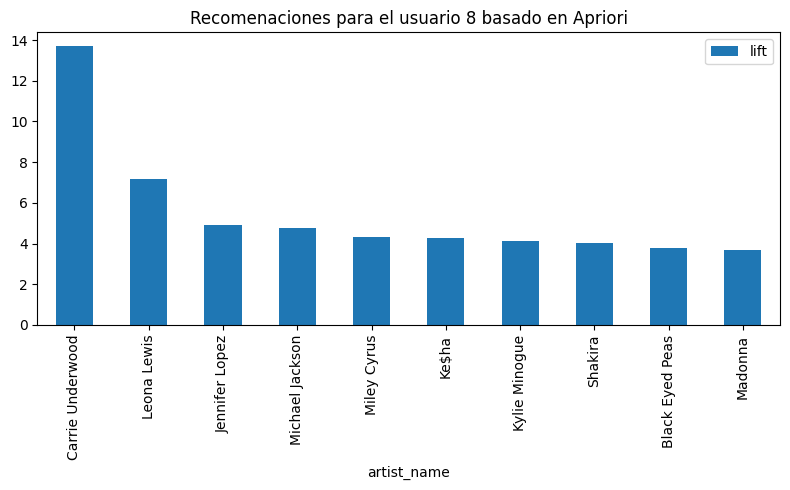

,artistID,support,confidence,lift,artist_name
69,1459.0,0.005814,0.550000,13.692105,Carrie Underwood
34,294.0,0.025899,0.604938,7.153395,Leona Lewis
37,299.0,0.023256,0.543210,4.917479,Jennifer Lopez
15,157.0,0.017970,0.666667,4.741855,Michael Jackson
61,461.0,0.085095,0.651822,4.312052,Miley Cyrus
67,466.0,0.055497,0.820312,4.287379,Ke$ha
9,55.0,0.043869,0.648437,4.116925,Kylie Minogue
68,701.0,0.045983,0.679688,4.031250,Shakira
51,306.0,0.074524,0.605150,3.766264,Black Eyed Peas
13,67.0,0.024313,0.836364,3.688578,Madonna


In [37]:
usuario_8_apriori = pd.merge(
    usuario_8_apriori,
    artistas[['artistID','artist_name']],
    on='artistID',
    how='left'
).sort_values(by='lift',ascending=False)
usuario_8_apriori = usuario_8_apriori.drop_duplicates(subset='artist_name')
usuario_8_apriori = usuario_8_apriori[:10]
fig, ax= plt.subplots(figsize=(8,5))
usuario_8_apriori.plot(kind="bar",x="artist_name",y="lift",ax=ax,title="Recomenaciones para el usuario 8 basado en Apriori")
plt.tight_layout()
plt.show()
usuario_8_apriori

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).
1. Preparamos los datos para usar el algoritmo Aprior, esto es, armar una lista de listas con los artistas que esuchó cada usuario. Se usa set para tener solo artistas unicos y evitar duplicados
2. Reglas:
    - suport 0.5%, al menos las reglas deben aparecer en el 0.5% de los usuarios.
    - confidence 50%, al menos 50% de probabilidad condicionada de la regla
    - min lift 3, debe ser 3 veces más probable la P(Y|X) que las probabilidades indpendientes
3. Se filtran los artistas que no ha escuchado el usuario 8
4. Se unen las tablas para mostrar los nombres de los artistas y se grafica


### 4. Recomendaciones generales 

De acuerdo con los resultados encontrados, en su opinión ¿qué procedimiento generó las mejores recomendaciones para este usuario? ¿Cómo implementaría una evaluación objetiva de estas recomendaciones? Justifique su respuesta.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).
* Promedios simples y ponderados: son acercameintos muy sencillos de implementar, sin emmabrgo, a la hora de recomendar lo hará con base en los artistas más populares en el conjnto y no en las preferencias del usuario
* Similitud coseno: Este es un acercamiento donde se pueden obtener recomendaciones colaborativas. Se pueden obtener buenos resultados personalizados basados en usuarios/artistas similares para recomendar. Este algoritmo no depdnde de las magnitudes de los vectores, sino de su dirección. Además sirve para matrices con alta dimensionalidad como lo es el caso.
* SVD: Este método puede capturar las relaciones y patrones subyacentes en los datos originales, convirtiendolo en un algoritmo muy fuerte para recomendar. Además, en las posiciones que habían cero, devuelve valores estimados, es decir estimaciones de que tanto le gustaría al usuario ese artista.
* Canasta de compra: Una desventaja es que va a depender de los hiperparametros del modelo, así que la subjetividad de analista juega un rol importante en este método. Sin embargo, produce resultados interpretables, aunque es limitado a la hora de las recomendaciones.

**Conclusión**
En general, el algoritmo de SVD puede ser el más robusto para las recomendaciones, sin embargo, tiene algunas limitaciones:
    - Si los usuarios son nuevos, va a tener un cold start para sus recomendaciones y habría que usar otro algoritmo para este tipo de usuarios.
    - Es el más costos computacionalmente y tendremos problemas a la hora de que ingresos nuevos usuarios y artistas ya que debemos calcular nuevamente los valores singualares.

**Evalaución objetiva:**
Se podría separar el df en entrenamiento y prueba para separar las reproducciones que ha tendio por artista. De esta forma cada método podría "aprender" una parte de los artistas escuchados por los usuarios y predecir los que quedan ocultos. En cada método se genera un top N. Luego se revisa si las predicciones están en el top N escuchados por el usuario para calcular cuántos aciertos tuvo cada método.